In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.10.18


# Import packages

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd


import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path


from cmdstanpy import CmdStanModel



# (Re)load your package
import TEXAS
# 1) Grab the low‐level functions you need

from TEXAS.stan.compiler import StanCompiler
from TEXAS.stan.sampler  import StanSampler
from TEXAS.stan.sampler import get_posterior, save_posterior
from TEXAS.stan.io import load_posterior
from TEXAS.plotting import *

import TEXAS
print(TEXAS.__version__)  

import importlib

import bayspline as bsl
import bayspar as bsr

from functools import partial
import pygwalker as pyg

0.1.0


# Miscellaneous functions

In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(66.6667,-18.6667),
        'schouten03':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:

    linear: schouten02, schouten03, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouten02':(0.015,0.280),
        'schouten03':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_crtp_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_crtp_linear':(69.61698822,-16.73443208),
        'low23_crtp_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_crtp_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_crtp_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_crtp_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)# Matplotlib plot
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

# Define local path

In [5]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/src/TEXAS /home/micromamba/app/src/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


# Data Import

In [6]:
fpath = f'{local_github_path}/spreadsheets/'
fname = 'ds03_processed_coretop_tex.csv'

raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df['scaledRI'] = raw_coretop_df['ringIndex']/4
raw_coretop_df['deltaRI_group'] = pd.cut(raw_coretop_df['deltaRI'],
                                            bins=[-np.inf, -0.3, 0.3, np.inf],
                                            labels=['<-0.3','-0.3 to 0.3','>0.3'])

raw_coretop_df['deltaRI_flip'] = raw_coretop_df['ringIndex'] - raw_coretop_df['TEX_RI']

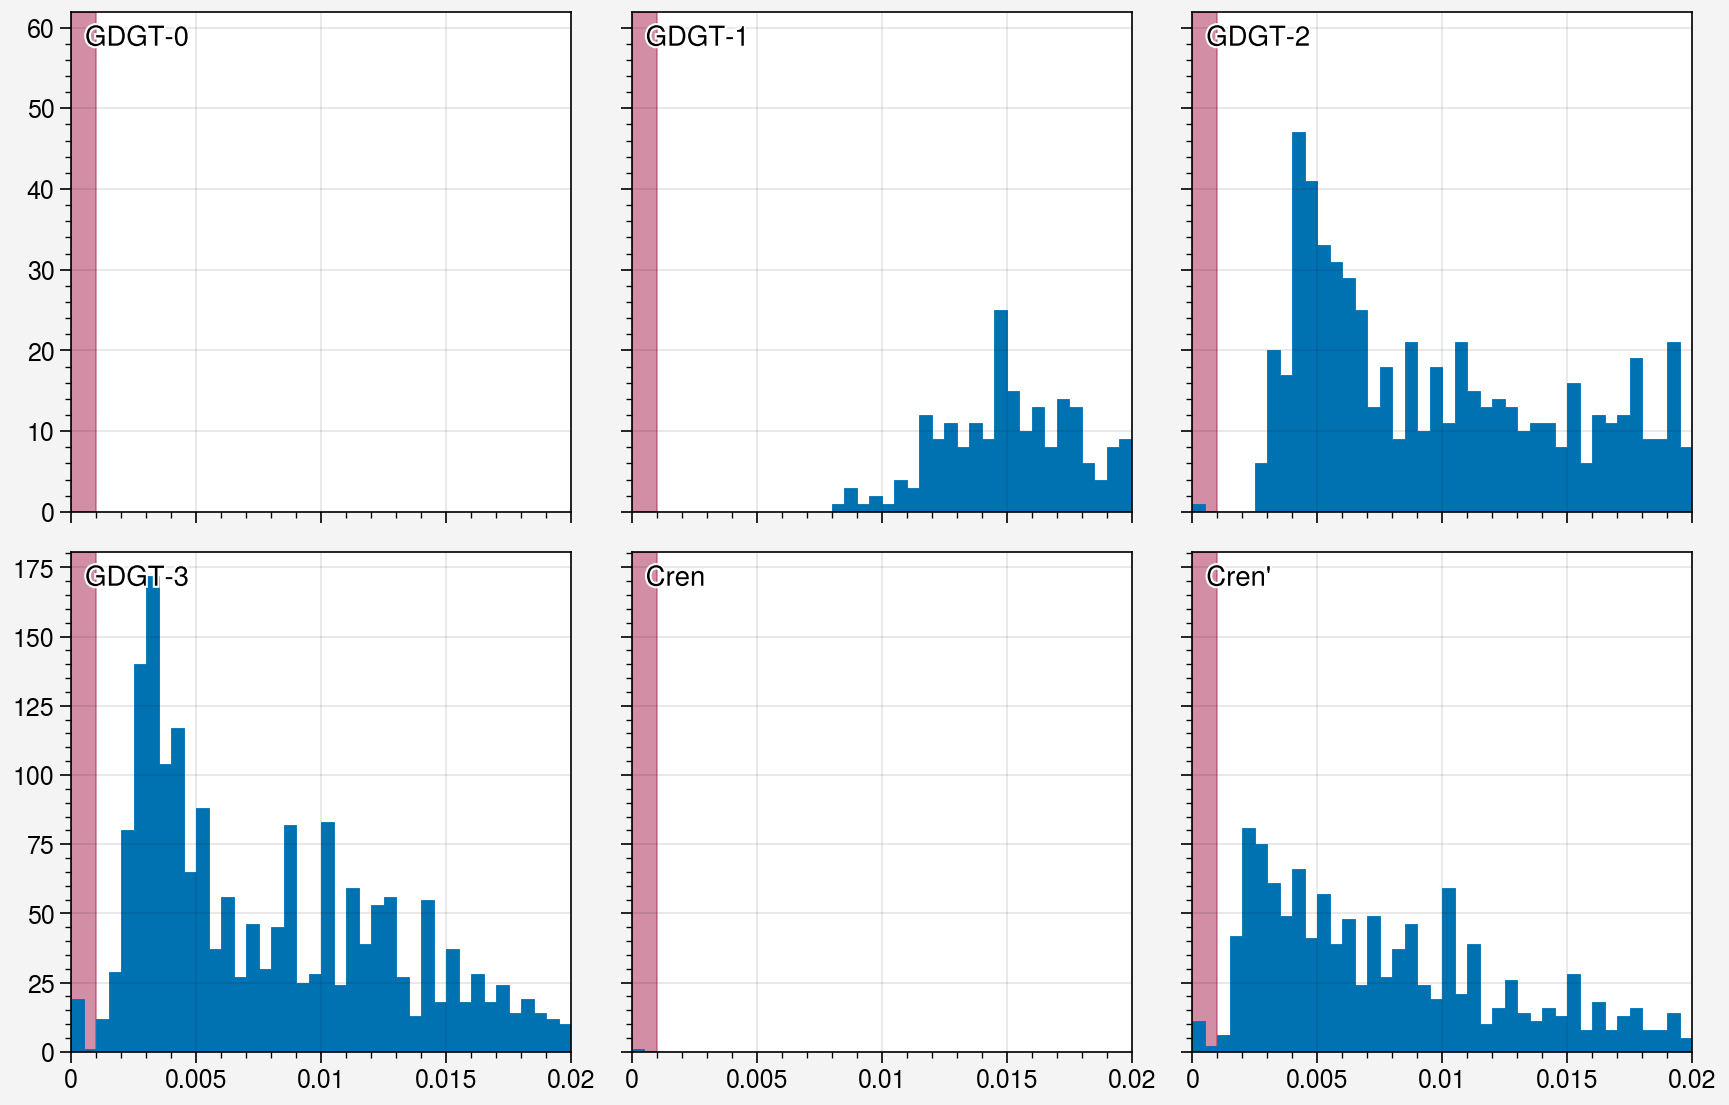

In [7]:
fig, axs = plot.subplots(ncols=3,nrows=2)

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
feature_labels = ['GDGT-0', 'GDGT-1', 'GDGT-2', 'GDGT-3', 'Cren', "Cren'"]
plot_data = raw_coretop_df.dropna(how='any',subset=features)

for i, (feature, label) in enumerate(zip(features, feature_labels)):
    ax = axs[i]
    ax.format(ultitle=f'{label}',fontweight='bold')
    XX = plot_data[feature].values
    ax.hist(XX,bins=np.arange(XX.min(),XX.max(),0.0005))
    
axs.format(xlim=(0,0.02))
axs.axvspan(0,0.001, color='pink9', alpha=0.5, edgecolor='none', zorder=0)

plt.show()

In [8]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
clean_coretop_df = raw_coretop_df[(raw_coretop_df['QC_flag']=='include') & (raw_coretop_df[features]>0.001).all(axis=1)].reset_index(drop=True)

clean_coretop_df['predRI_multiv_g23r'] = TEXAS.ensemble.generate_ensemble_auto(
            post_ds=load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
            x_vals=clean_coretop_df['thermocline_T_depthIntegral'],
            gdgt23ratio=clean_coretop_df['gdgt23ratio'], # if 'use_gdgt23ratio' in sel_post_ds.attrs else np.full(len(plot_data),0),  # Required for multivariate models
            n_draws=500,
            seed=42
        )['p50']
clean_coretop_df['RIres_multiv_g23r'] = clean_coretop_df['scaledRI'] - clean_coretop_df['predRI_multiv_g23r']

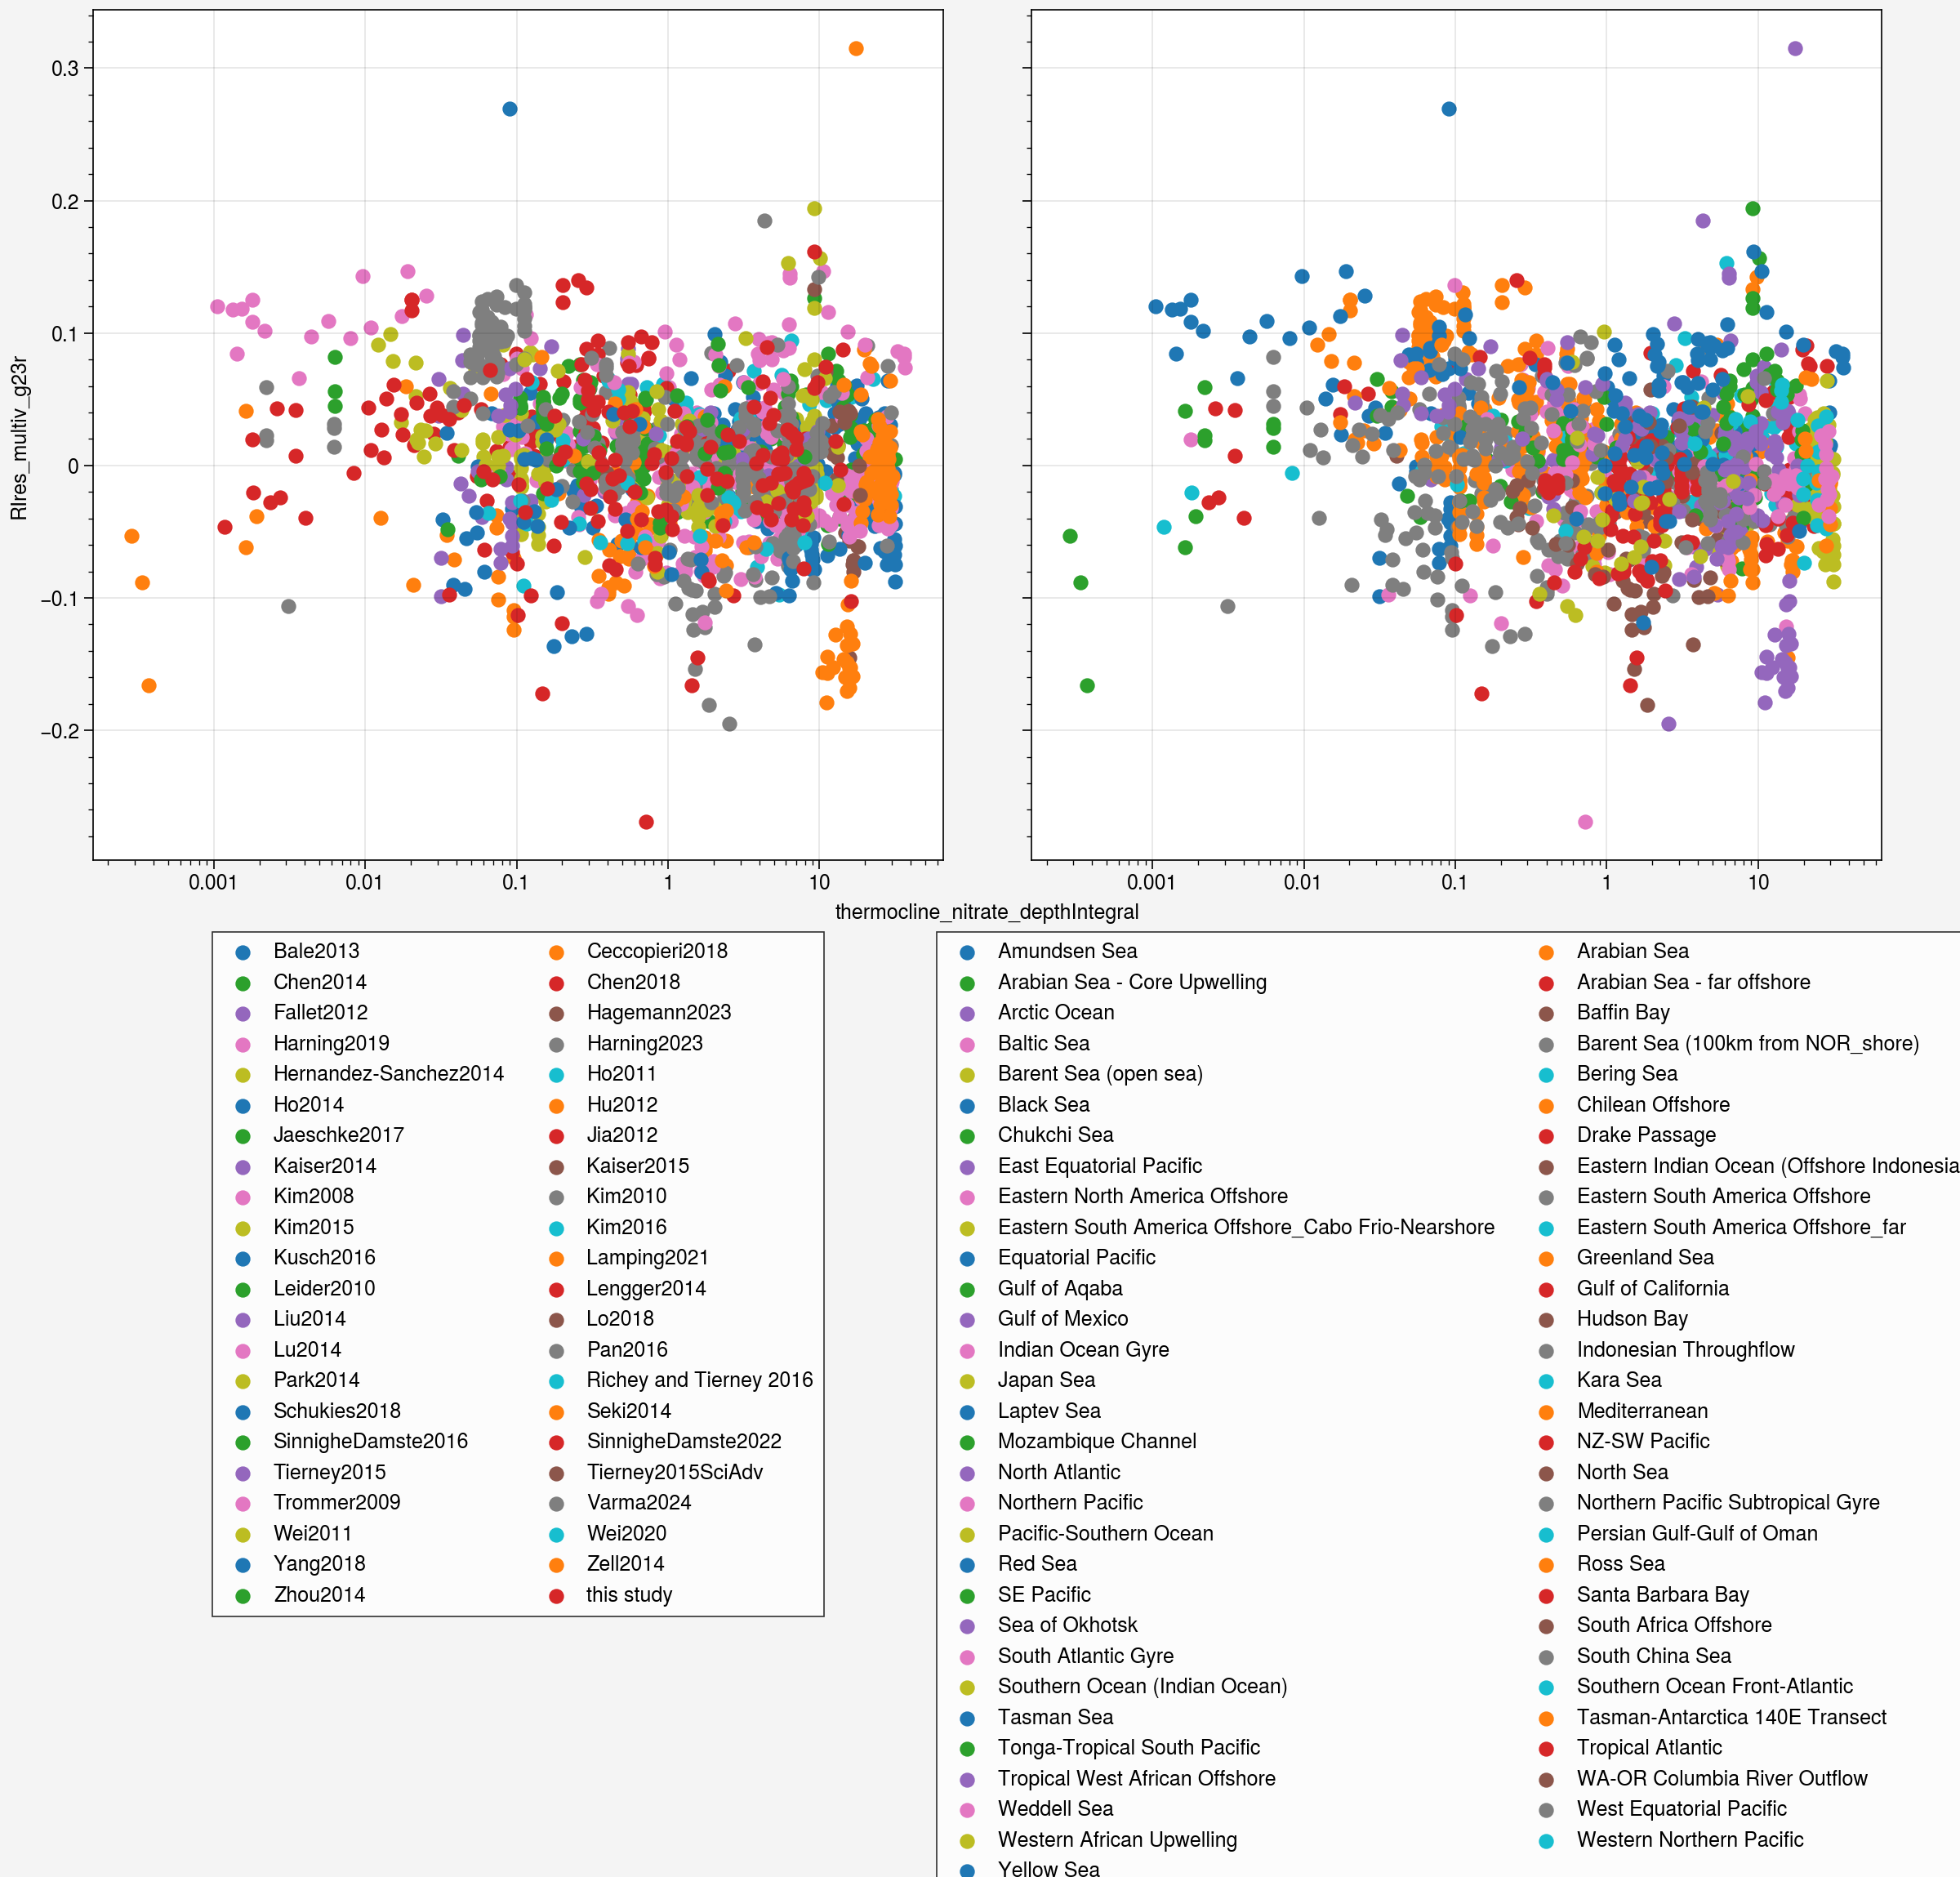

In [9]:
fig, axs = plot.subplots(ncols=2,width=12)

plot_data = clean_coretop_df
grouped = plot_data.groupby('reference_name')
for name, group in grouped:
    plot_x = group['thermocline_nitrate_depthIntegral']
    plot_y = group['RIres_multiv_g23r']

    ax = axs[0]
    ax.scatter(plot_x,plot_y,cycle='tab10',label=name)
    ax.format(
        xscale='log'
    )
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h,l,loc='b',ncols=2, fontsize=8)


grouped2 = plot_data.groupby('regionName')
for name2, group2 in grouped2:
    plot_x = group2['thermocline_nitrate_depthIntegral']
    plot_y = group2['RIres_multiv_g23r']

    ax = axs[1]
    ax.scatter(plot_x,plot_y,cycle='tab10',label=name2)
    ax.format(
        xscale='log'
    )
h2, l2 = axs[1].get_legend_handles_labels()
axs[1].legend(h2,l2,loc='b',ncols=2, fontsize=8)

In [10]:
fpath = f'{local_github_path}/spreadsheets'
fname = 'global_hydrothermal_vents.csv'

glob_hydrovent = pd.read_csv(os.path.join(fpath,fname))
glob_hydrovent['longitude'] = pd.to_numeric(glob_hydrovent['longitude'], errors='coerce')
glob_hydrovent['latitude'] = pd.to_numeric(glob_hydrovent['latitude'], errors='coerce')
glob_hydrovent = glob_hydrovent.dropna(how='any',subset=['longitude','latitude'])
glob_hydrovent

,Name,longitude,latitude,Site Activity,Activity,Tectonic setting,Spreading Rate,Depth
0,Kagamil Island,-169.7200,52.980000,VolcanicArc-active,active,arc volcano,NotApplicable,5
1,Piip Submarine Volcano,167.2717,55.416700,VolcanicArc-active,active,arc volcano,NotApplicable,500-382
2,Paramushir Island,155.5000,49.666700,VolcanicArc-inactive,inactive,arc volcano,NotApplicable,800
3,Kraternaya Bight; Ushishir Volcano,152.8000,47.516667,VolcanicArc-active,active,arc volcano,NotApplicable,60-0
4,Hot Beach; Mendeleev Volcano,145.7360,43.976000,VolcanicArc-active,active,arc volcano,NotApplicable,1-0
...,...,...,...,...,...,...,...,...
549,SEIR; 21,79.1030,-41.252000,MOR-unconfirmed,unconfirmed,MOR,65.9,2800
550,SEIR; 16,79.7530,-41.772000,MOR-unconfirmed,unconfirmed,MOR,66.3,2800
551,SEIR; 10,81.8380,-41.802000,MOR-unconfirmed,unconfirmed,MOR,67.1,2540
552,SEIR; 01,88.0420,-42.113000,MOR-unconfirmed,unconfirmed,MOR,68.5,2400


In [11]:
from sklearn.neighbors import BallTree

threshold_km = 5
R_km = 6371.0088

df1 = clean_coretop_df
df2 = glob_hydrovent
# radians
df1_rad = np.deg2rad(df1[['Latitude','Longitude']].to_numpy())
df2_rad = np.deg2rad(df2[['latitude','longitude']].to_numpy())

# build tree on df2 points
tree = BallTree(df2_rad, metric='haversine')

# query all df1 points within radius (in radians)
radius = threshold_km / R_km
neighbors = tree.query_radius(df1_rad, r=radius)

# label: near if at least one match, else far
dist_rad, _ = tree.query(df1_rad, k=1)   # nearest neighbor
df1['dist_km'] = (dist_rad.flatten() * R_km)
df1['near_far'] = np.where(df1['dist_km'] <= threshold_km, 'near', 'far')

df1.columns

Index(['sampleID', 'index_column', 'core_name', 'core_type',
       'sample_depth_start', 'sample_depth_end', 'Latitude', 'Longitude',
       'modernWaterDepth', 'TEX86', 'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
       'fGDGT_cren', 'fGDGT_cren_prime', 'BIT', 'publicationYear',
       'reference_name', 'remark', 'reference_link', 'dataset_DOI',
       'ringIndex', 'scaledRI', 'gdgt23ratio', 'methaneIndex',
       'gdgtZeroOverZeroCren', 'TEX_RI', 'deltaRI', 'QC_flag', 'match_lat',
       'match_lon', 'match_depth', 'SST', 'thermocline_depth', 'thermocline_T',
       'thermocline_T_depthIntegral', 'SSN', 'thermocline_nitrate',
       'thermocline_nitrate_depthIntegral', 'region_ID', 'regionName',
       'mahalanobis_distance', 'mahalanobis_distance_weights',
       'mahalanobis_outlier', 'deltaRI_group', 'deltaRI_flip',
       'predRI_multiv_g23r', 'RIres_multiv_g23r', 'dist_km', 'near_far'],
      dtype='object')

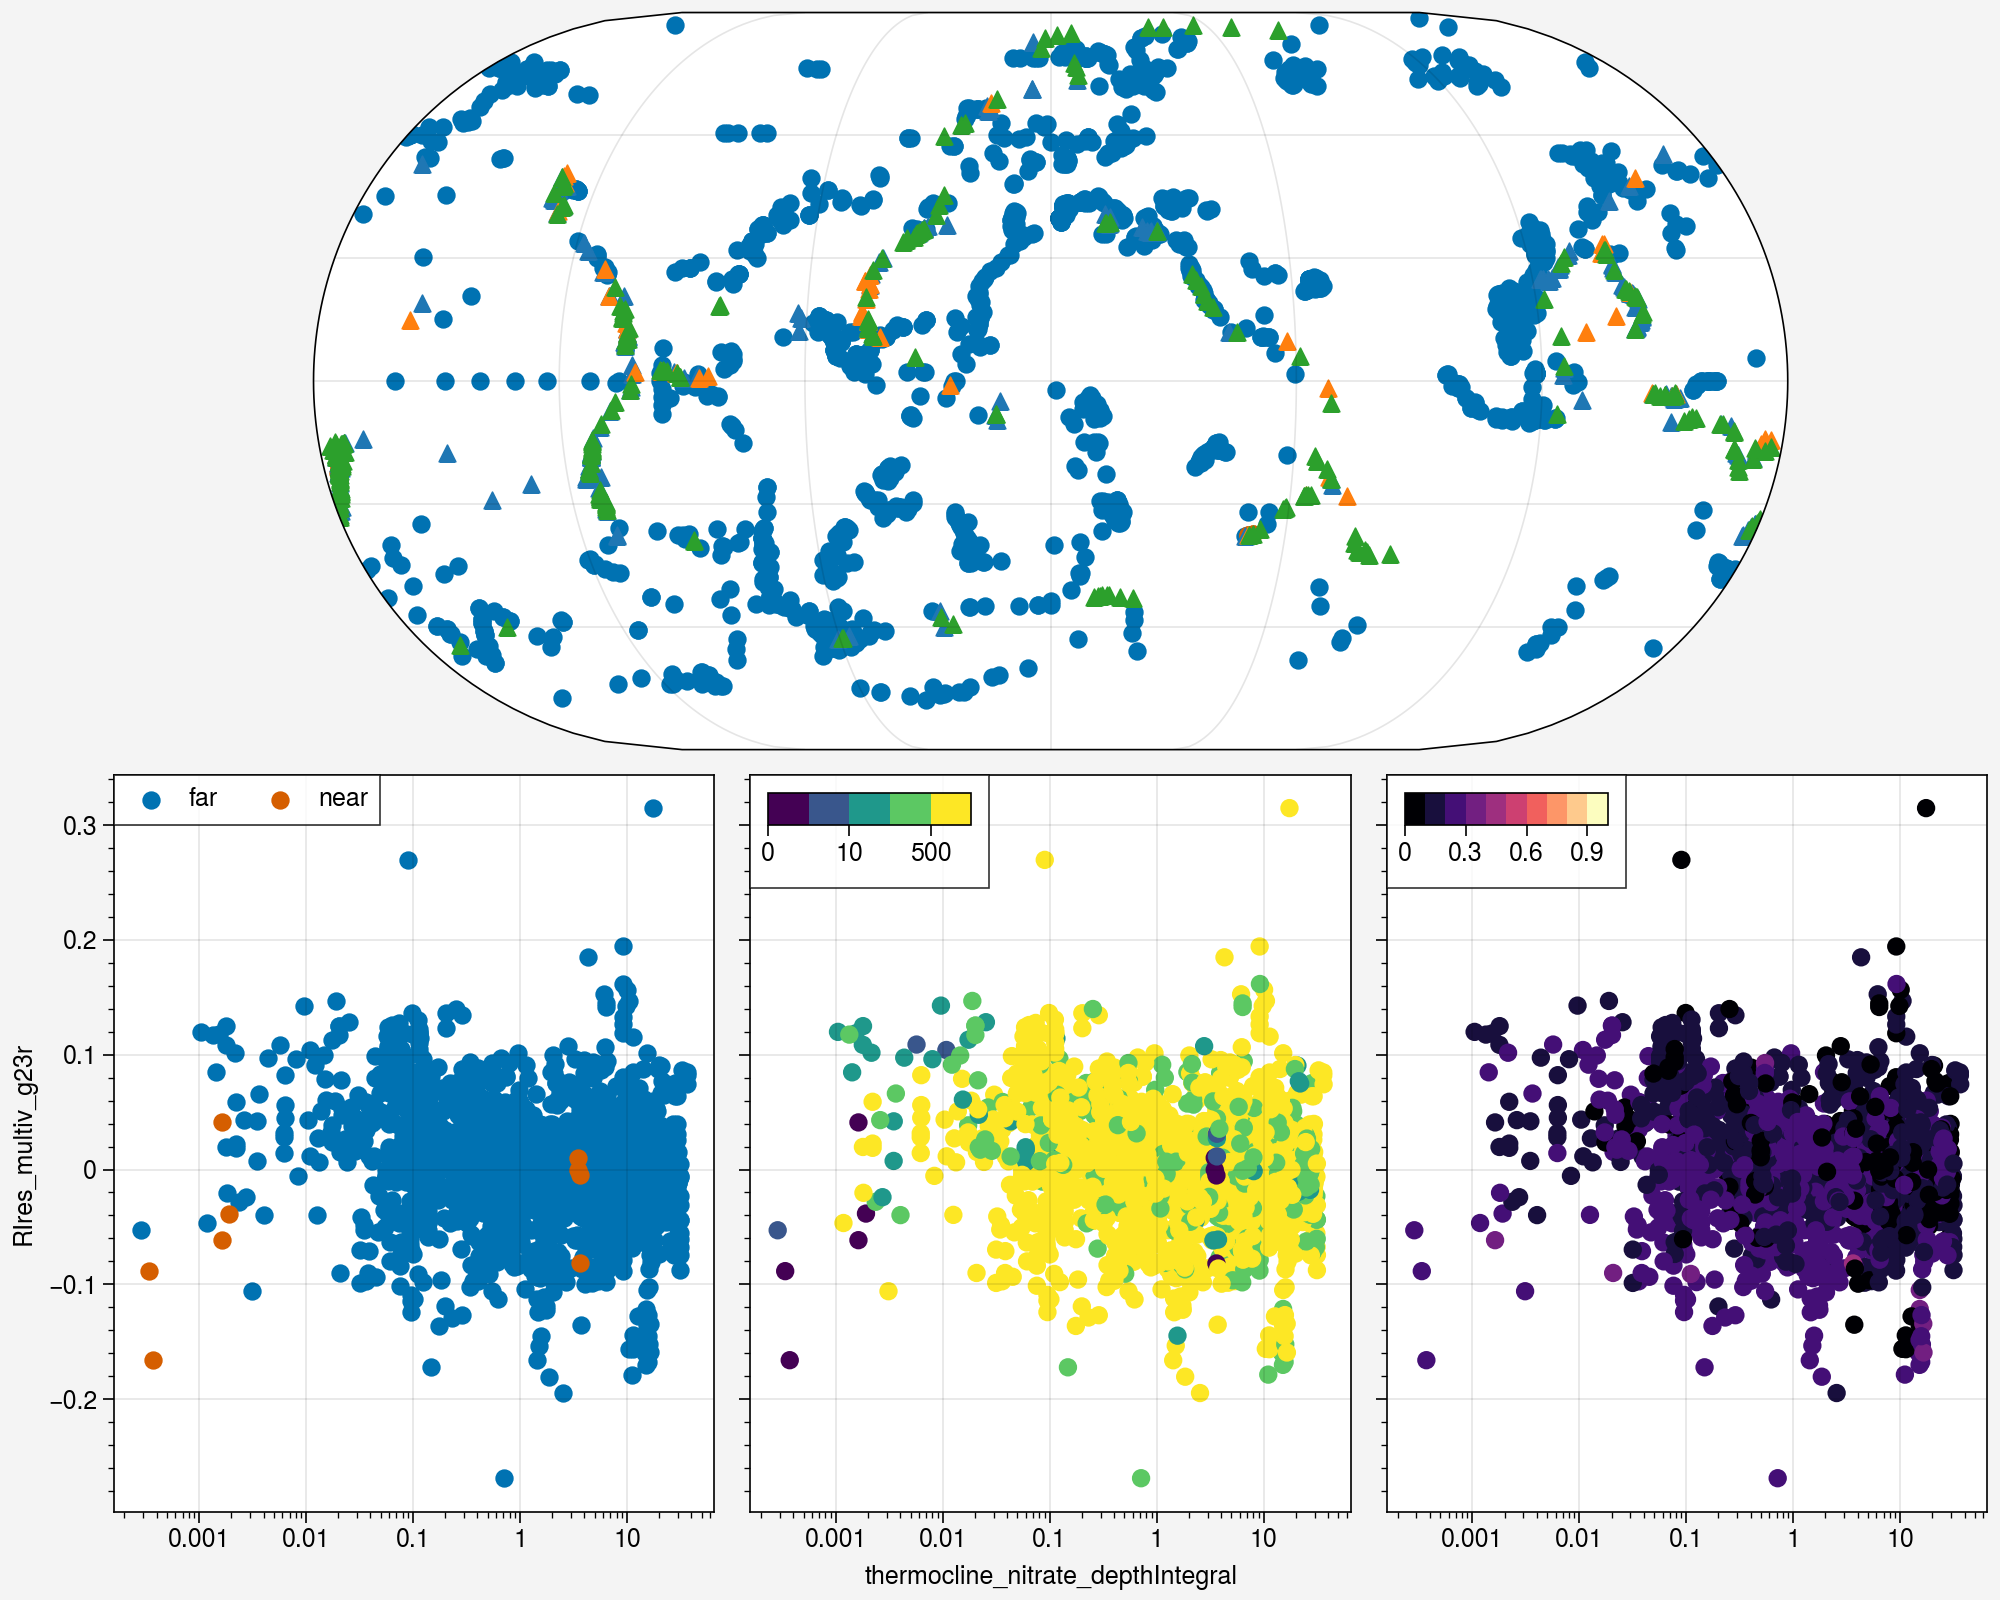

In [12]:
array = [
    [1,1,1],
    [2,3,4]
]

fig, axs = plot.subplots(array,figsize=(10,8),proj=('eck3',None))

ax = axs[0]
grouped = df1.groupby('near_far')
for name, group in grouped:
    plot_x = group['Longitude']
    plot_y = group['Latitude']
    ax.scatter(plot_x,plot_y)
    
    plot_x2 = group['thermocline_nitrate_depthIntegral']
    plot_y2 = group['RIres_multiv_g23r']
    axs[1].scatter(plot_x2,plot_y2,label=name)
    
grouped_hydrovent = glob_hydrovent.groupby('Activity')
for name, group in grouped_hydrovent:
    plot_x = group['longitude']
    plot_y = group['latitude']
    ax.scatter(plot_x.astype(float),plot_y.astype(float),m='^',cycle='tab10')

ax = axs[2]
plot_data = df1
plot_x = plot_data['thermocline_nitrate_depthIntegral']
plot_y = plot_data['RIres_multiv_g23r']
plot_c = plot_data['dist_km']
m = ax.scatter(plot_x,plot_y,c=plot_c,cmap='viridis',levels=[0,5,10,100,500,1000])
ax.colorbar(m, loc='ul')

ax = axs[3]
plot_data = df1
plot_x = plot_data['thermocline_nitrate_depthIntegral']
plot_y = plot_data['RIres_multiv_g23r']
plot_c = plot_data['methaneIndex']
m = ax.scatter(plot_x,plot_y,c=plot_c,cmap='magma',levels=np.arange(0,1.1,0.1))
ax.colorbar(m, loc='ul')

axs[1,:].format(xscale='log')

h1, l1 = axs[1].get_legend_handles_labels()
axs[1].legend(h1,l1,loc='ul')

(0.0, 10.0)

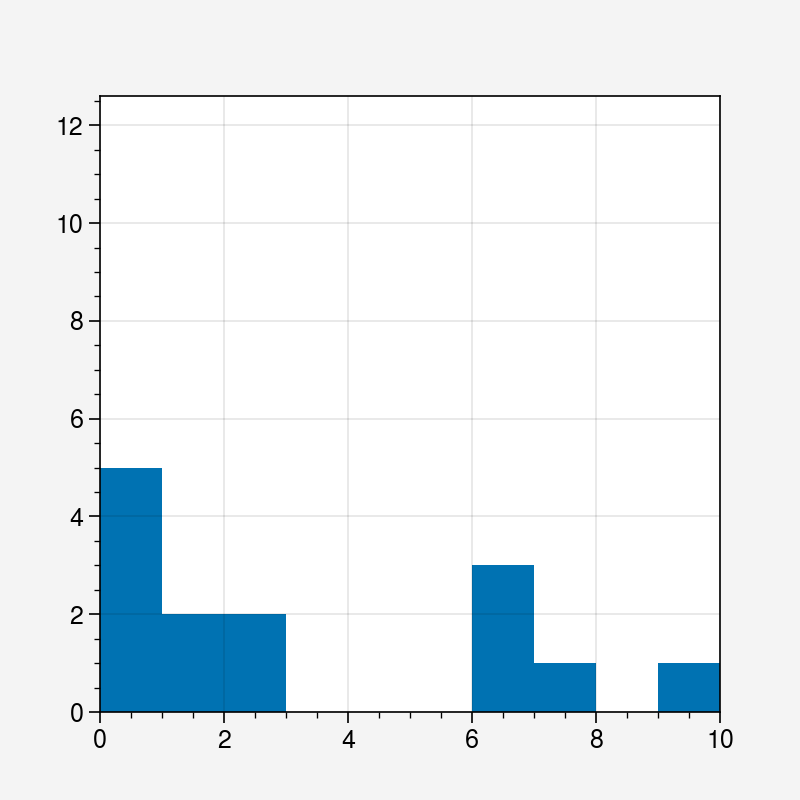

In [13]:
plt.hist(df1.dist_km,bins=np.arange(0,3501,1))
plt.xlim(0,10)

# Main Figures

## Figure 1: Global Coretop Map

        _ Nitrosopumilus_maritimus
      ,|
      |, Acidilobus_saccharovorans
      ||
      || Sulfolobus_acidocaldarius
     _|
    | | Nitrosoarchaeum_koreensis
    | |
   _| | Thermoplasma_acidophilum
  | |
  | |       ___________________ Nitrosopumilus_piranensis
  | |______|
  |        |_____________________________ Nitrosopumilus_ureiphilus
  |
  | Desulfurococcus_mucosus
  |
  |_ Nitrosotenuis_chungbukensis
  |
 ,, Saccharolobus_solfataricus
 ||
 || Picrophilus_torridus
 ||
 |, Metallosphaera_sedula
 ||
 || Methanocaldococcus_jannaschii
 ||
 || Thermoproteus_tenax
 |
 |, Nitrosopumilus_adriaticus
_,|
 || Candidatus_Nitrosopelagicus_brevis
 |
 | Halobacterium_salinarum
 |
 | Escherichia_coli



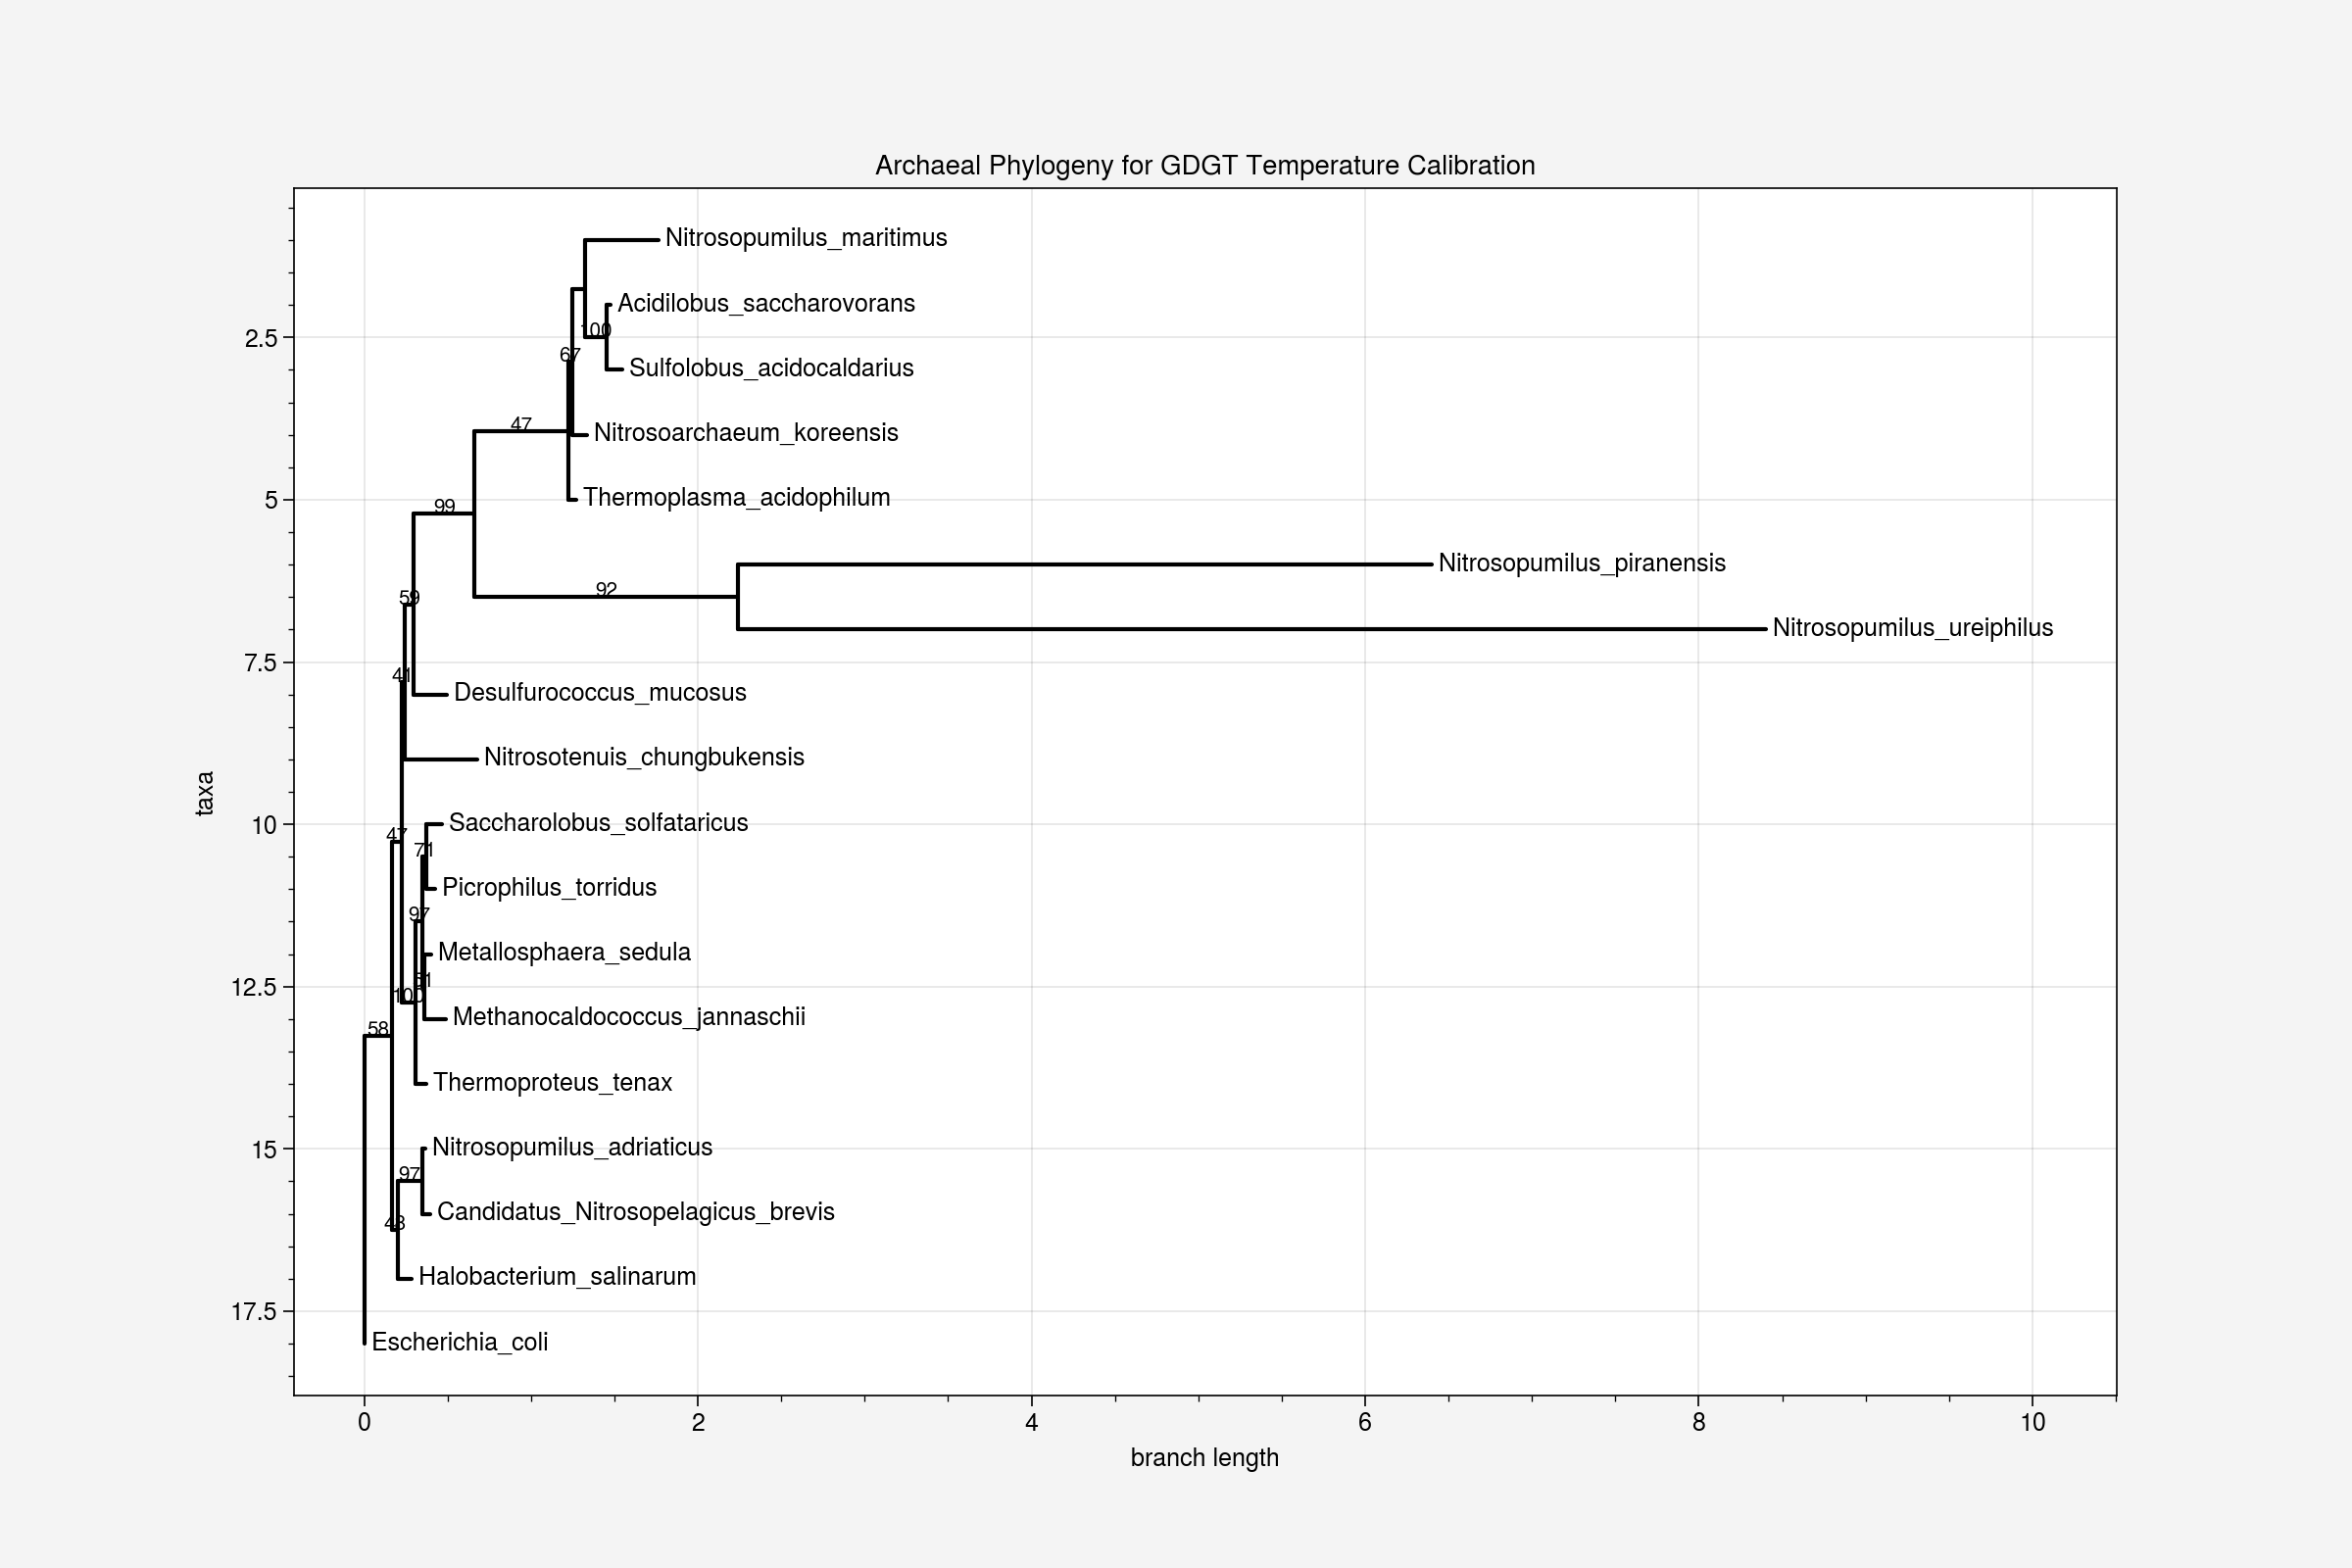

In [24]:
from Bio import Phylo

tree_file = f"{local_github_path}/data/phylo/trees/texas_archaeal_tree.treefile"
tree = Phylo.read(tree_file, "newick")

# This reorders the tree using E. coli as the most distant relative
tree.root_with_outgroup('Escherichia_coli')

Phylo.draw_ascii(tree)
# Matplotlib plot
fig, ax = plt.subplots(figsize=(12, 8))
Phylo.draw(tree, axes=ax, do_show=False)
ax.set_title("Archaeal Phylogeny for GDGT Temperature Calibration")
plt.show()

In [27]:
fpath = f'{local_github_path}/data/spreadsheets/'
fname = 'culture_mesocosm_combined_rev_030425.csv'
raw_culmeso_df = pd.read_csv(os.path.join(fpath, fname))
raw_culmeso_df.columns

Index(['sampleID', 'sampleName', 'Source', 'Temperature', 'TEX86', 'ringIndex',
       'scaledRI', 'gdgt23ratio', 'phyloT_order', 'GTDB_phylum', 'NCBI_phylum',
       'GTDB_class', 'NCBI_class', 'GTDB_order', 'NCBI_order', 'GTDB_family',
       'NCBI_family', 'GTDB_genus', 'NCBI_genus', 'GTDB_species',
       'NCBI_species', 'Strains', 'experiment_setup', 'organism_broadClass',
       'organism_broadClass2', 'organism_broadClass3', 'fGDGT_0', 'fGDGT_1',
       'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime', 'datatype',
       'methaneIndex', 'gdgtZeroOverZeroCren', 'BIT', 'violin_bins'],
      dtype='object')

In [17]:
fpath = f'{local_github_path}/data/spreadsheets/'
df = pd.read_csv(f'{fpath}culture_mesocosm_combined_rev_030425.csv')

print('TAXONOMIC COLUMNS IN YOUR DATA:')
print('=' * 40)

# Check species-related columns
species_cols = ['GTDB_species', 'NCBI_species', 'GTDB_genus', 'NCBI_genus', 'Strains']

for col in species_cols:
    if col in df.columns:
        unique_count = df[col].nunique()
        non_null = df[col].notna().sum()
        print(f'{col}: {unique_count} unique values, {non_null}/{len(df)} non-null')
        
        # Show first few unique values
        unique_vals = df[col].dropna().unique()[:5]
        print(f'  Examples: {list(unique_vals)}')
        print()

print('\\nSample of your data:')
cols_to_show = ['sampleName', 'Temperature', 'TEX86'] + [col for col in species_cols if col in df.columns]
print(df[cols_to_show].head())

TAXONOMIC COLUMNS IN YOUR DATA:
GTDB_species: 11 unique values, 123/177 non-null
  Examples: ['s__Nitrosopumilus maritimus', 's__Nitrosopumilus adriaticus', 's_Nirosopumilus piranensis', 's__Nitrosopumilus ureiphilus', 's__Nitrosoarchaeum koreensis']

NCBI_species: 11 unique values, 123/177 non-null
  Examples: ['s__Nitrosopumilus maritimus', 's__Nitrosopumilus adriaticus', 's_Nirosopumilus piranensis', 's__Nitrosopumilus ureiphilus', 's__Nitrosoarchaeum koreensis']

GTDB_genus: 17 unique values, 177/177 non-null
  Examples: ['g__Nitrosotenuis', 'g__Nitrosopumilus', 'g__Nitrosarchaeum', 'g__Nitrososphaera', 'g__Cenarchaeum']

NCBI_genus: 17 unique values, 177/177 non-null
  Examples: ['g__Nitrosotenuis', 'g__Nitrosopumilus', 'g__Nitrosarchaeum', 'g__Nitrososphaera', 'g__Cenarchaeum']

Strains: 33 unique values, 177/177 non-null
  Examples: ['N4', 'NAOA2', 'NAOA6', 'SCM1', 'NF5']

\nSample of your data:
                                          sampleName  Temperature     TEX86  \
0  Ba

In [19]:
df.columns

Index(['sampleID', 'sampleName', 'Source', 'Temperature', 'TEX86', 'ringIndex',
       'scaledRI', 'gdgt23ratio', 'phyloT_order', 'GTDB_phylum', 'NCBI_phylum',
       'GTDB_class', 'NCBI_class', 'GTDB_order', 'NCBI_order', 'GTDB_family',
       'NCBI_family', 'GTDB_genus', 'NCBI_genus', 'GTDB_species',
       'NCBI_species', 'Strains', 'experiment_setup', 'organism_broadClass',
       'organism_broadClass2', 'organism_broadClass3', 'fGDGT_0', 'fGDGT_1',
       'fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime', 'datatype',
       'methaneIndex', 'gdgtZeroOverZeroCren', 'BIT', 'violin_bins'],
      dtype='object')